# Limpieza y Analisis a detalle de la base de datos


In [142]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sys.path.append("..")  # subir un nivel

#

from scripts import bases as b, init_notebook as init, limpieza as lim

ctx = init.init_notebook()

df_pacientes = ctx["df_pacientes"]

Cargando datos de pacientes...
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  → 29,696 registros | 27,294 pacientes únicos
  → 1,681 traslados reconstruidos
Cargando datos geográficos...
  → 15 hospitales con coordenadas
  → 9 municipios AMBA cargados

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29696
Pacientes únicos:   27294
Hospitales únicos:  15
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4023

Distribución tipo_egreso:
tipo_egreso
alta           17519
traslado        5330
otro            3580
muerte          2791
desconocido      476
Name: count, dtype: int64

Distribución evolución:
evolucion
 0    27147
-1     1392
 1      944
-2      200
 2       13
Name: count, dtype: int64


ordenar, limpiar columnas, quitar ids inconsistentes

In [143]:
df = lim.renombrar_columnas(df_pacientes)
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
# ordenar por episodio
df = df.sort_values(["paciente_id", "fecha_inicio"])


## Detectar IDs inconsistentes
ids_problematicos = df.groupby("paciente_id").agg(
    edad_unicos=("edad", "nunique"),
    sexo_unicos=("sexo", "nunique")
)

ids_problematicos = ids_problematicos[
    (ids_problematicos["edad_unicos"] > 1) |
    (ids_problematicos["sexo_unicos"] > 1)
]

# # Version mas flexible
# ids_problematicos = df.groupby("paciente_id").agg(
#     edad_min=("edad", "min"),
#     edad_max=("edad", "max"),
#     sexo_unicos=("sexo", "nunique")
# )

# ids_problematicos = ids_problematicos[
#     (ids_problematicos["edad_max"] - ids_problematicos["edad_min"] > 2) |
#     (ids_problematicos["sexo_unicos"] > 1)
# ]

## Ver cuántos son
cantidad_ids_malos = ids_problematicos.shape[0]
total_ids = df["paciente_id"].nunique()

print("IDs problemáticos:", cantidad_ids_malos)
print("Total IDs:", total_ids)
print("Porcentaje:", cantidad_ids_malos / total_ids)

## Eliminarlos
df_limpio = df[
    ~df["paciente_id"].isin(ids_problematicos.index)
].copy()

## Chequeo sanity
df_limpio.groupby("paciente_id").agg(
    edad_unicos=("edad", "nunique"),
    sexo_unicos=("sexo", "nunique")
).max()

df=df_limpio

IDs problemáticos: 89
Total IDs: 27294
Porcentaje: 0.003260789917197919


In [144]:
# Crear episodios utilizando la función estandarizada en bases.py

# b.identificar_episodios detecta nuevos episodios basados en 'alta' o 'muerte'
# y marca una 'alerta_gap' si el tiempo entre registros es > 2 días sin romper el episodio.
df = b.identificar_episodios(
    df, 
    col_id='paciente_id', 
    col_fecha='fecha_inicio', 
    col_motivo='motivo_egreso',
    umbral_alerta_dias=2
)

print('Episodios identificados.')
df[['paciente_id', 'fecha_inicio', 'motivo_egreso', 'episodio_id', 'alerta_gap']].head(10)


Episodios identificados.


,paciente_id,fecha_inicio,motivo_egreso,episodio_id,alerta_gap
14987,6,2020-06-08 12:11:19,muerte,1,False
15017,7,2020-06-07 12:11:19,NaN,1,False
12081,10,2020-06-06 12:11:16,otro,1,False
12066,100,2020-05-27 12:11:16,traslado-otro,1,False
12067,150,2020-06-03 12:11:16,otro,1,False
12068,152,2020-06-03 12:11:16,alta-domiciliaria,1,False
12069,154,2020-06-03 12:11:16,otro,1,False
12070,155,2020-06-05 12:11:16,traslado-extra-sanitario,1,False
12071,156,NaT,otro,1,False
12072,157,2020-06-05 12:11:16,alta-domiciliaria,1,False


In [145]:
# Consolidar episodios y resumir información clave
df_ep = df.groupby(['paciente_id', 'episodio_id']).agg(
    hospital_inicial=('hospital_id', 'first'),
    hospital_final=('hospital_id', 'last'),
    fecha_inicio=('fecha_inicio', 'first'),
    fecha_egreso=('fecha_egreso', 'last'),
    tipo_ingreso=('tipo_ingreso', 'first'),
    tipo_final=('tipo_final', 'last'),
    motivo_cierre=('motivo_egreso', 'last'),
    fallecio=('murio', 'max'),
    n_traslados=('hospital_id', lambda x: len(x) - 1),
    alerta_gap=('alerta_gap', 'any'), # Si algún tramo tuvo demora
    recorrido=('hospital_nombre', lambda x: ' -> '.join(x.tolist())),
    duracion_total_dias=('duracion_dias', 'sum'),
    paso_criticas=('paso_criticas', 'max')
).reset_index()

print(f'Total episodios reconstruidos: {len(df_ep)}')
df_ep.head()


Total episodios reconstruidos: 27657


,paciente_id,episodio_id,hospital_inicial,hospital_final,fecha_inicio,fecha_egreso,tipo_ingreso,tipo_final,motivo_cierre,fallecio,n_traslados,alerta_gap,recorrido,duracion_total_dias,paso_criticas
0,6,1,8,8,2020-06-08 12:11:19,2020-06-28 12:11:19,criticas,criticas,muerte,True,0,False,ONATIVIA,20.0,si
1,7,1,8,8,2020-06-07 12:11:19,NaT,intermedias,intermedias,NaN,False,0,False,ONATIVIA,0.0,no
2,10,1,7,7,2020-06-06 12:11:16,2020-06-12 12:11:16,criticas,criticas,otro,False,0,False,LUCIO MELENDEZ,6.0,si
3,100,1,7,7,2020-05-27 12:11:16,2020-06-03 12:11:16,generales,intermedias,traslado-otro,False,0,False,LUCIO MELENDEZ,7.0,no
4,150,1,7,7,2020-06-03 12:11:16,2020-06-05 12:11:16,intermedias,intermedias,otro,False,0,False,LUCIO MELENDEZ,2.0,no


## ¿Qué es `df_ep` y cómo usarlo?

`df_ep` es un DataFrame donde cada fila representa un **episodio de internación completo**. 
Un episodio puede incluir uno o varios tramos (traslados) entre hospitales mientras no haya un alta definitiva.

### Consultas Comunes:

- **Recorridos:** La columna `recorrido` muestra la secuencia de hospitales.
- **Alertas de Tiempo:** La columna `alerta_gap` indica episodios donde un traslado tardó más de lo habitual (> 2 días), lo que podría indicar saturación o falta de datos.
- **Tasas:** Puedes calcular tasas de mortalidad o traslado agrupando por `tipo_ingreso` (situación inicial del paciente).


In [146]:
# 1. ¿Cuántos episodios tienen traslados lentos (alerta_gap)?
gap_count = df_ep['alerta_gap'].sum()
print(f'Episodios con posibles demoras en traslados: {gap_count}')

# 2. Ver los episodios con más traslados
print('\nEpisodios con más movimientos:')
display(df_ep.sort_values('n_traslados', ascending=False)[['paciente_id', 'n_traslados', 'recorrido', 'fallecio']].head(5))

# 3. Filtrar por un hospital específico al final de la trayectoria
hosp_target = 10 # Ejemplo: Evita Pueblo
terminaron_ahi = df_ep[df_ep['hospital_final'] == hosp_target]
print(f'\nEpisodios que terminaron en el hospital {hosp_target}: {len(terminaron_ahi)}')


Episodios con posibles demoras en traslados: 467

Episodios con más movimientos:


,paciente_id,n_traslados,recorrido,fallecio
13038,MF69,8,UPA 5 AB -> MODULO HOSPITALARIO 9 AB -> MODULO...,False
14746,NV93,6,UPA 5 AB -> MODULO HOSPITALARIO 9 AB -> MODULO...,False
1452,BH66,5,UPA 5 AB -> MODULO HOSPITALARIO 9 AB -> MODULO...,False
681,AO28,4,UPA 5 AB -> MODULO HOSPITALARIO 9 AB -> MODULO...,False
132,AB52,4,UPA 5 AB -> MODULO HOSPITALARIO 9 AB -> MODULO...,False



Episodios que terminaron en el hospital 10: 1653


In [147]:
# Análisis de tasas y probabilidades por episodio

# 1. Probabilidad de que un episodio termine en fallecimiento según el nivel inicial de ingreso
print('Probabilidad de fallecer según tipo de ingreso al episodio:')
morf_por_ingreso = df_ep.groupby('tipo_ingreso')['fallecio'].agg(['mean', 'count'])
print(morf_por_ingreso)

# 2. Probabilidad de ser trasladado al menos una vez según el nivel inicial
df_ep['tuvo_traslado'] = df_ep['n_traslados'] > 0
print('\nProbabilidad de traslado según tipo de ingreso:')
print(df_ep.groupby('tipo_ingreso')['tuvo_traslado'].mean())

# 3. Distribución de cantidad de traslados por episodio
print('\nDistribución de la cantidad de traslados por episodio:')
print(df_ep['n_traslados'].value_counts(normalize=True).sort_index() * 100)

# 4. Relación entre traslados y mortalidad
print('\nMortalidad según cantidad de traslados en el episodio:')
print(df_ep.groupby('n_traslados')['fallecio'].mean())


Probabilidad de fallecer según tipo de ingreso al episodio:
                  mean  count
tipo_ingreso                 
criticas      0.365548   2711
generales     0.025948   3430
intermedias   0.078732  21516

Probabilidad de traslado según tipo de ingreso:
tipo_ingreso
criticas       0.036518
generales      0.009913
intermedias    0.070273
Name: tuvo_traslado, dtype: float64

Distribución de la cantidad de traslados por episodio:
n_traslados
0    94.052139
1     5.369346
2     0.462812
3     0.083162
4     0.021694
5     0.003616
6     0.003616
8     0.003616
Name: proportion, dtype: float64

Mortalidad según cantidad de traslados en el episodio:
n_traslados
0    0.098339
1    0.127273
2    0.195312
3    0.043478
4    0.166667
5    0.000000
6    0.000000
8    0.000000
Name: fallecio, dtype: float64


In [148]:
orden = {"generales": 1, "intermedias": 2, "criticas": 3}

df_ep["nivel_ingreso"] = df_ep["tipo_ingreso"].map(orden)
df_ep["nivel_final"] = df_ep["tipo_final"].map(orden)

df_ep["evolucion"] = df_ep["nivel_final"] - df_ep["nivel_ingreso"]

In [149]:
# episodios por paciente
df_ep.groupby("paciente_id").size().describe()

# valores raros
df_ep["evolucion"].value_counts()

# mortalidad
df_ep["fallecio"].mean()

np.float64(0.10030010485591351)

In [150]:
len(df_ep)

27657

In [151]:
len(df), len(df_ep)
df_ep[["paciente_id", "episodio_id"]].duplicated().sum()
df_ep.groupby("paciente_id").size().describe()
df_ep.groupby("paciente_id").size().sort_values(ascending=False)


df_ep["duracion_calc"] = (
    df_ep["fecha_egreso"] - df_ep["fecha_inicio"]
).dt.days
(df_ep["duracion_calc"] - df_ep["duracion_total_dias"]).describe()

# validar evolucion
df_ep["evolucion"].value_counts()
# validar muertes
df_ep.groupby("nivel_ingreso")["fallecio"].mean()


# H1
df_ep.groupby("paso_criticas")["fallecio"].mean()


# H2/H3 : pacientes que mueren sin empeorar
df_ep[
    (df_ep["evolucion"] <= 0) &
    (df_ep["fallecio"] == 1)
].head(10)




# VISUAL
id_test = df["paciente_id"].dropna().sample(1).values[0]

df[df["paciente_id"] == id_test].sort_values("fecha_inicio")




,hospital_id,hospital_nombre,paciente_id,fecha_inicio,estado_ingreso,tipo_ingreso,estado_final,tipo_final,sexo,edad,...,paso_generales,duracion_dias,tipo_egreso,murio,nivel_ingreso,nivel_final,evolucion,nuevo_episodio,episodio_id,alerta_gap
2745,2,MI PUEBLO,KI68,2021-03-09 12:11:08,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,62.0,...,no,20.0,alta,False,2,2,0,True,1,False


## Diagnóstico de Calidad: Motivos de Cierre de Episodios

Para que un episodio sea considerado "cerrado" correctamente en nuestro modelo, debe terminar en `alta-domiciliaria` o `muerte`. 
Cualquier otro valor indica un episodio que quedó abierto o cuya resolución final no es definitiva (traslados no seguidos, datos truncados, etc.).

In [152]:
# 1. Contar episodios por motivo_cierre
validos = ['alta-domiciliaria', 'muerte']
resumen_cierre = df_ep['motivo_cierre'].value_counts(dropna=False).to_frame(name='frecuencia_abs')
resumen_cierre['porcentaje'] = df_ep['motivo_cierre'].value_counts(dropna=False, normalize=True) * 100
resumen_cierre['es_valido'] = resumen_cierre.index.isin(validos)

print('Resumen de motivos de cierre:')
display(resumen_cierre)

# 2. Porcentajes globales
df_ep['es_valido'] = df_ep['motivo_cierre'].isin(validos)
pct_validos = df_ep['es_valido'].mean() * 100

print(f"\n>>> EPISODIOS VÁLIDOS (Alta/Muerte): {pct_validos:.2f}%")
print(f">>> EPISODIOS INVÁLIDOS (Traslados/Otros): {100 - pct_validos:.2f}%")

Resumen de motivos de cierre:


,frecuencia_abs,porcentaje,es_valido
motivo_cierre,,,
alta-domiciliaria,17461,63.134107,True
muerte,2774,10.030010,True
otro,2561,9.259862,False
traslado-otro,2516,9.097154,False
anulado,932,3.369852,False
traslado-hospital-de-la-red,683,2.469538,False
NaN,434,1.569223,False
traslado-extra-sanitario,296,1.070253,False



>>> EPISODIOS VÁLIDOS (Alta/Muerte): 73.16%
>>> EPISODIOS INVÁLIDOS (Traslados/Otros): 26.84%


In [153]:
# 3. Listar tipos inválidos ordenados
invalidez_detalle = resumen_cierre[~resumen_cierre['es_valido']].sort_values('frecuencia_abs', ascending=False)
print('Tipos de cierre inválidos más frecuentes:')
display(invalidez_detalle)

# 4. Verificar patrones en inválidos
df_inv = df_ep[~df_ep['es_valido']].copy()

print('\nAnalizando patrones en episodios inválidos:')
print(f"- Duración total media: {df_inv['duracion_total_dias'].mean():.2f} días")
print(f"- Mediana de traslados: {df_inv['n_traslados'].median()}")
print(f"- % con Alerta de Gap (>2 días): {df_inv['alerta_gap'].mean()*100:.2f}%")
print(f"- % de episodios con UN SOLO registro (n_traslados=0): {(df_inv['n_traslados'] == 0).mean()*100:.2f}%")

# Sospecha de timestamps (duración 0)
duracion_cero = (df_inv['duracion_total_dias'] <= 0).mean() * 100
print(f"- % de episodios con duración <= 0 días: {duracion_cero:.2f}%")

Tipos de cierre inválidos más frecuentes:


,frecuencia_abs,porcentaje,es_valido
motivo_cierre,,,
otro,2561,9.259862,False
traslado-otro,2516,9.097154,False
anulado,932,3.369852,False
traslado-hospital-de-la-red,683,2.469538,False
NaN,434,1.569223,False
traslado-extra-sanitario,296,1.070253,False



Analizando patrones en episodios inválidos:
- Duración total media: 7.54 días
- Mediana de traslados: 0.0
- % con Alerta de Gap (>2 días): 1.40%
- % de episodios con UN SOLO registro (n_traslados=0): 94.07%
- % de episodios con duración <= 0 días: 33.23%


In [154]:
# 5. Mostrar ejemplos de episodios inválidos
print('Ejemplos de episodios que NO terminan en alta o muerte:')
columnas_ver = ['paciente_id', 'recorrido', 'duracion_total_dias', 'motivo_cierre', 'n_traslados']
display(df_inv[columnas_ver].sample(min(10, len(df_inv))))

# Detalle de un caso si es útil
if len(df_inv) > 0:
    id_ejemplo = df_inv.iloc[0]['paciente_id']
    print(f'\nDetalle del paciente {id_ejemplo} en la base original:')
    display(df[df['paciente_id'] == id_ejemplo][['hospital_nombre', 'fecha_inicio', 'fecha_egreso', 'motivo_egreso']])

Ejemplos de episodios que NO terminan en alta o muerte:


,paciente_id,recorrido,duracion_total_dias,motivo_cierre,n_traslados
2145,BZ70,EL CRUCE,1.0,traslado-otro,0
23224,VU90,ONATIVIA,0.0,anulado,0
9647,JA75,ONATIVIA,0.0,anulado,0
5876,FL96,OLLER,0.0,otro,0
18715,RO68,UPA 5 AB,0.0,traslado-hospital-de-la-red,0
22457,VB08,UPA 5 AB,2.0,otro,0
16529,PO62,UPA 5 AB,2.0,traslado-otro,0
18727,RO95,MI PUEBLO,0.0,NaN,0
13316,MM93,ONATIVIA,9.0,traslado-otro,0
13047,MF89,MODULO HOSPITALARIO 11 FV,6.0,traslado-otro,0



Detalle del paciente 7 en la base original:


,hospital_nombre,fecha_inicio,fecha_egreso,motivo_egreso
15017,ONATIVIA,2020-06-07 12:11:19,NaT,NaN


# 4. Análisis de Transiciones y Probabilidades de la Red

En esta sección, filtramos los episodios para trabajar únicamente con trayectorias "cerradas" (alta domiciliaria o muerte) y analizamos la dinámica de movimientos de los pacientes.

In [155]:
# Filtrar episodios válidos (Alta o Muerte)
valid_motives = ['alta-domiciliaria', 'muerte']
df_ep = df_ep[df_ep['motivo_cierre'].isin(valid_motives)].copy()

# Filtrar tramos en df original para que coincidan con los episodios válidos
df = df[df.set_index(['paciente_id', 'episodio_id']).index.isin(df_ep.set_index(['paciente_id', 'episodio_id']).index)].copy()

print(f"Episodios válidos para análisis: {len(df_ep)}")
print(f"Registros (tramos) totales: {len(df)}")

Episodios válidos para análisis: 20235
Registros (tramos) totales: 21581


In [246]:
def graficar_grafo_transicion(matriz, titulo, node_size=2500, font_size=12, k=1.5, pos=None, curva=True):
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np
    
    G = nx.DiGraph()
    for i in matriz.index:
        for j in matriz.columns:
            weight = matriz.loc[i, j]
            if weight > 0: 
                G.add_edge(str(i), str(j), weight=weight)
    
    if pos is None:
        pos = nx.spring_layout(G, k=k, seed=42)
    
    plt.figure(figsize=(14, 9))
    
    node_colors = []
    for node in G.nodes():
        node_upper = node.upper()
        if any(x in node_upper for x in ["POBLA", "ORIGEN"]):
            node_colors.append('#3498db') # Azul para fuente
        elif any(x in node_upper for x in ["ALTA"]):
            node_colors.append('#2e8b57') # verde para sumidero: alta
        elif any(x in node_upper for x in ["MUERTE", "FIN"]):
            node_colors.append('#e74c3c') # Rojo para sumidero: muerte
        elif "RED" == node_upper:
            node_colors.append('#f1c40f') 
        else:
            node_colors.append('#ffde21') 
            
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, alpha=0.9, edgecolors='white', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=font_size, font_family='sans-serif', font_weight='bold')
    
    edges = list(G.edges(data=True))
    if edges:
        weights = np.array([d['weight'] for u, v, d in edges])
        widths = 1.5 + weights * 15 
        edge_colors = [(0.1 + 0.8 * w, 0.1 * (1 - w), 0.1 * (1 - w)) for w in weights]
        
        rad = 0.15 if curva else 0
        margin = (node_size**0.5) + 8
        
        nx.draw_networkx_edges(
            G, pos, width=widths, edge_color=edge_colors, 
            arrowsize=25, alpha=0.6, 
            connectionstyle=f"arc3,rad={rad}",
            min_source_margin=30,
            min_target_margin=25
        )
        
        # POSICIONAMIENTO MANUAL DE ETIQUETAS SOBRE EL ARCO
        for (u, v, d) in edges:
            p1 = np.array(pos[u])
            p2 = np.array(pos[v])
            mid = (p1 + p2) / 2
            diff = p2 - p1
            length = np.linalg.norm(diff)
            if length == 0: continue
            
            # Vector normal para desplazar la etiqueta hacia el arco


            sign = np.sign(rad) if rad != 0 else 1

            normal = -sign * np.array([-diff[1], diff[0]]) / length


            extra_offset = (np.sqrt(node_size)) / 1800 if curva else 0 # probá entre 0.1 y 0.3
            label_off = normal * (length * abs(rad) * 0.6 + extra_offset)

            lp = mid + label_off
            
            plt.text(lp[0], lp[1], f"{d['weight']:.1%}", 
                     fontsize=font_size-2, color='black', 
                     ha='center', va='center', fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7, ec='none'))
    
    plt.title(titulo, fontsize=font_size+6, pad=30, fontweight='bold')
    plt.axis('off')
    plt.show()

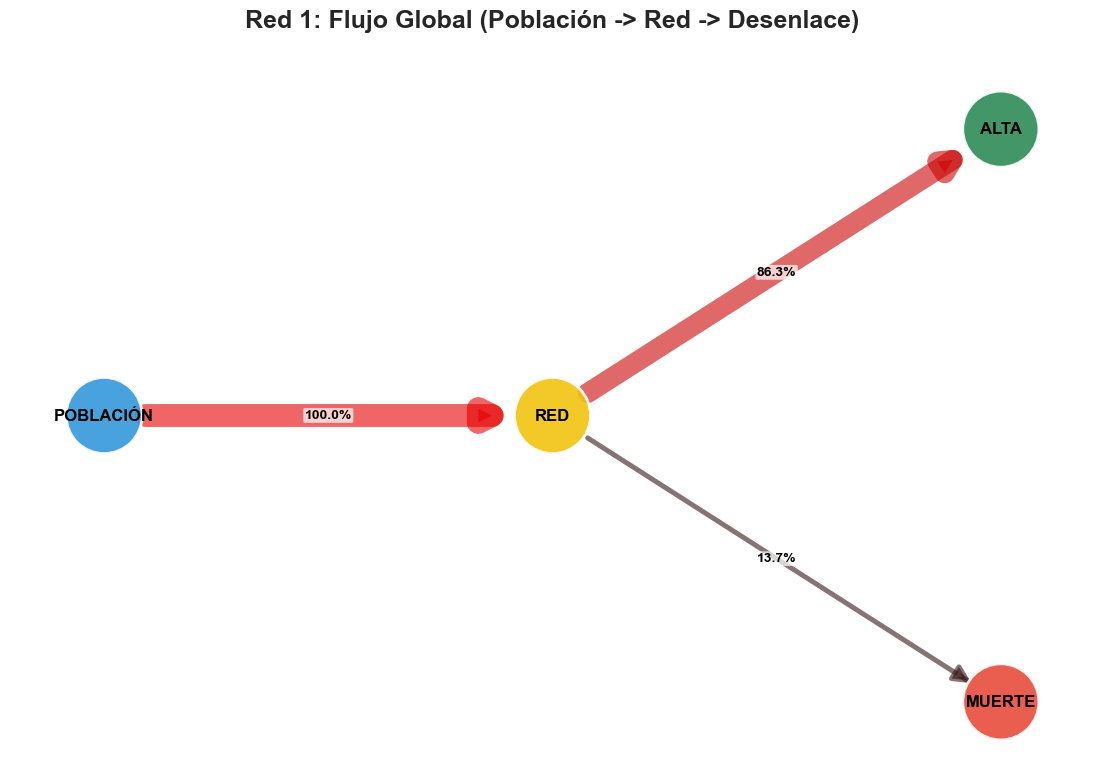

In [247]:
# Red 1: Población -> Red -> {Alta, Muerte}
n_total = len(df_ep)
p_muerte = df_ep['fallecio'].mean()
p_alta = 1 - p_muerte

matriz_red1 = pd.DataFrame(0.0, index=['POBLACIÓN', 'RED'], columns=['RED', 'ALTA', 'MUERTE'])
matriz_red1.loc['POBLACIÓN', 'RED'] = 1.0
matriz_red1.loc['RED', 'ALTA'] = p_alta
matriz_red1.loc['RED', 'MUERTE'] = p_muerte

pos_red1 = {'POBLACIÓN': (-1, 0), 'RED': (0, 0), 'ALTA': (1, 0.5), 'MUERTE': (1, -0.5)}
graficar_grafo_transicion(matriz_red1, 'Red 1: Flujo Global (Población -> Red -> Desenlace)', node_size=3000, pos=pos_red1, curva=False)

,N,Traslado,Muerte,Alta
Paso,,,,
Hospi 1,20235,6.0%,12.6%,81.4%
Hospi 2,1205,9.3%,15.7%,75.0%
Hospi 3,112,14.3%,22.3%,63.4%
Hospi 4,16,43.8%,6.2%,50.0%
Hospi 5,7,28.6%,14.3%,57.1%
Hospi 6,2,100.0%,0.0%,0.0%
Hospi 7,2,50.0%,0.0%,50.0%


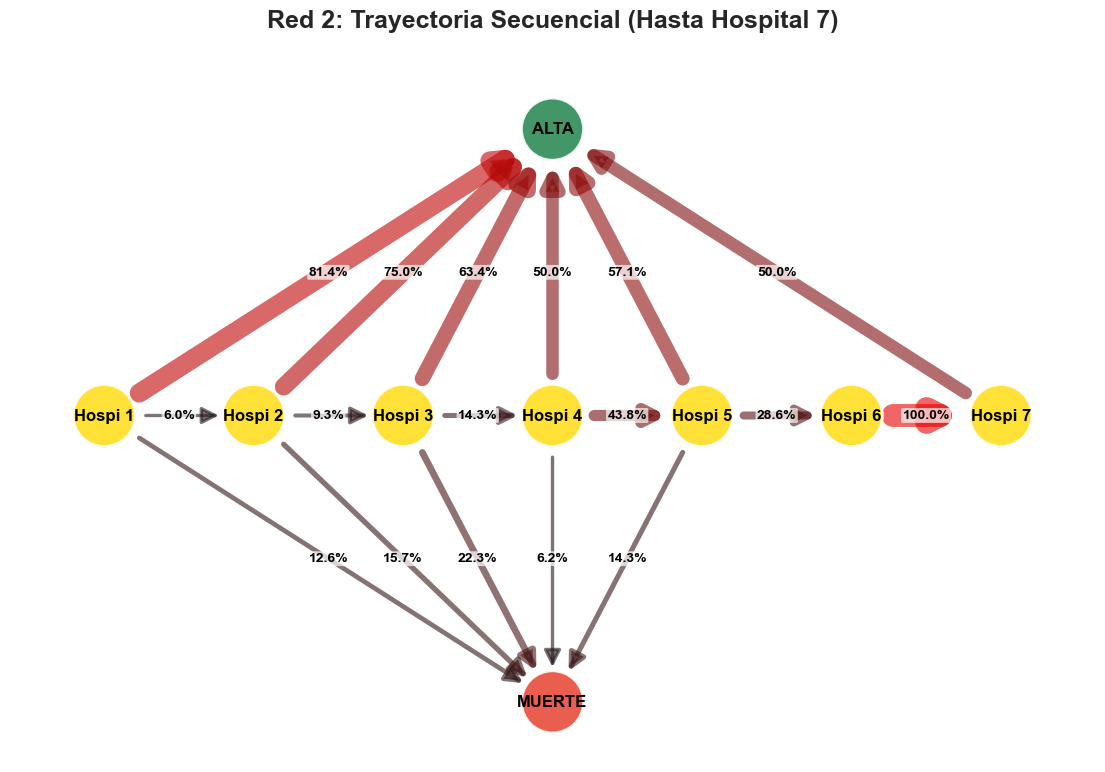

In [248]:
### Red 2: Trayectoria Secuencial (Hasta Hospital 7)
df['paso_n'] = df.groupby(['paciente_id', 'episodio_id']).cumcount() + 1
df['tiene_siguiente'] = df.groupby(['paciente_id', 'episodio_id'])['hospital_nombre'].shift(-1).notna()

resumen_pasos = []
for i in range(1, 8): 
    subset = df[df['paso_n'] == i]
    if len(subset) == 0: break
    n = len(subset)
    p_traslado = subset['tiene_siguiente'].mean()
    p_muerte = (subset['murio'] & ~subset['tiene_siguiente']).mean()
    p_alta = (~subset['murio'] & ~subset['tiene_siguiente']).mean()
    resumen_pasos.append({'Paso': f'Hospi {i}', 'N': n, 'Traslado': p_traslado, 'Muerte': p_muerte, 'Alta': p_alta})

df_resumen_pasos = pd.DataFrame(resumen_pasos).set_index('Paso')
display(df_resumen_pasos.style.format({'Traslado': '{:.1%}', 'Muerte': '{:.1%}', 'Alta': '{:.1%}'}))

edges_seq = []
for i, row in df_resumen_pasos.iterrows():
    idx = int(i.split()[-1])
    if row['Traslado'] > 0 and idx < 7: 
        edges_seq.append({'Origen': i, 'Destino': f'Hospi {idx+1}', 'Prob': row['Traslado']})
    if row['Alta'] > 0: edges_seq.append({'Origen': i, 'Destino': 'ALTA', 'Prob': row['Alta']})
    if row['Muerte'] > 0: edges_seq.append({'Origen': i, 'Destino': 'MUERTE', 'Prob': row['Muerte']})

df_edges_seq = pd.DataFrame(edges_seq)
matriz_seq = df_edges_seq.pivot(index='Origen', columns='Destino', values='Prob').fillna(0)

pos_seq = {f'Hospi {i}': (i, 0) for i in range(1, 8)}
pos_seq['ALTA'] = (4, 1)
pos_seq['MUERTE'] = (4, -1)
graficar_grafo_transicion(matriz_seq, 'Red 2: Trayectoria Secuencial (Hasta Hospital 7)', node_size=2000, pos=pos_seq, curva=False)

In [249]:
# ### Red 3: Red de Derivaciones Hospitalarias (Con Población Sumidero)

# # Recorrido completo tramo a tramo
# transiciones = []
# for _, group in df.groupby(['paciente_id', 'episodio_id']):
#     hospitales = group['hospital_nombre'].tolist()
#     # sumidero solicitado: POBLACIÓN
#     final_status = 'POBLACIÓN' if not group['murio'].iloc[-1] else 'MUERTE'
    
#     for i in range(len(hospitales)-1):
#         if hospitales[i] != hospitales[i+1]:
#             transiciones.append({'Origen': hospitales[i], 'Destino': hospitales[i+1]})
    
#     transiciones.append({'Origen': hospitales[-1], 'Destino': final_status})

# df_trans = pd.DataFrame(transiciones)
# matriz_hosp = pd.crosstab(df_trans['Origen'], df_trans['Destino'], normalize='index')

# # Disposición en 2 capas para hospitales
# hosp_nodos = sorted([n for n in matriz_hosp.index if n.startswith('Hospi') or (not any(x in n.upper() for x in ['POBLA','MUERTE']) and n != 'POBLACIÓN' and n != 'MUERTE')])
# n_hosp = len(hosp_nodos)
# pos_hosp = {}
# for i, h in enumerate(hosp_nodos):
#     if i < (n_hosp + 1) // 2:
#         pos_hosp[h] = (i*3, 1)
#     else:
#         pos_hosp[h] = ((i - (n_hosp+1)//2)*3 + 1.5, -1)

# pos_hosp['POBLACIÓN'] = (n_hosp * 1.8, 0.5)
# pos_hosp['MUERTE'] = (n_hosp * 1.8, -0.5)

# graficar_grafo_transicion(matriz_hosp, 'Red 3: Derivaciones entre Hospitales (Sumidero: POBLACIÓN)', node_size=2500, font_size=8, pos=pos_hosp)

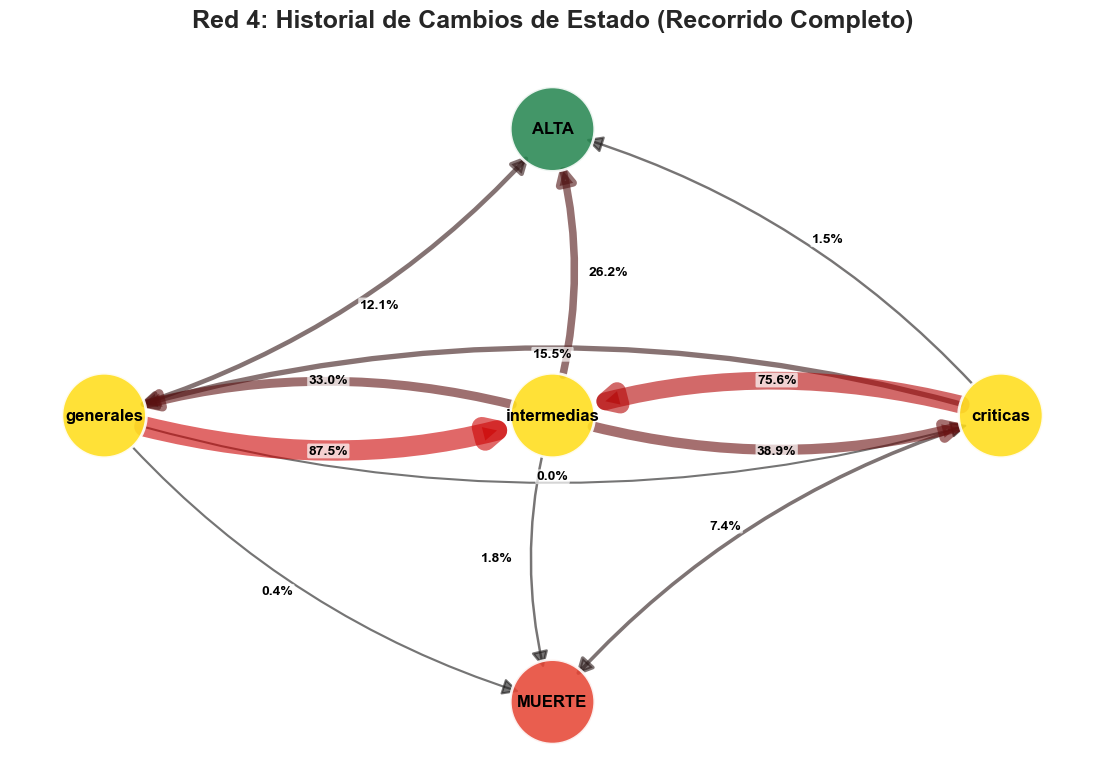

In [252]:
### Red 4: Reconstrucción del Historial Clínico (Niveles de Cuidado)

trans_niveles = []
orden_niv = {'generales': 1, 'intermedias': 2, 'criticas': 3}

for _, group in df.groupby(['paciente_id', 'episodio_id']):
    final_status = 'ALTA' if not group['murio'].iloc[-1] else 'MUERTE'
    
    sequence = []
    # Usar df_pacientes/df (granular) para reconstruir paso a paso
    for _, row in group.iterrows():
        ing = str(row['tipo_ingreso']).lower()
        fin = str(row['tipo_final']).lower()
        
        # Inicio del tramo
        if not sequence or sequence[-1] != ing:
            sequence.append(ing)
            
        # Reconstruir pasos intermedios si las flags están presentes
        # (ej. entró en general, terminó en crítica pero pasó por intermedia)
        n_ing = orden_niv.get(ing, 0)
        n_fin = orden_niv.get(fin, 0)
        
        if n_ing != 0 and n_fin != 0:
            steps = []
            if row['paso_generales']: steps.append('generales')
            if row['paso_intermedias']: steps.append('intermedias')
            if row['paso_criticas']: steps.append('criticas')
            
            # Si empeoró, ordenamos ascendente; si mejoró, descendente
            if n_ing <= n_fin:
                steps = sorted(steps, key=lambda x: orden_niv.get(x, 0))
            else:
                steps = sorted(steps, key=lambda x: orden_niv.get(x, 0), reverse=True)
                
            for s in steps:
                if sequence[-1] != s:
                    sequence.append(s)
        
        # Fin del tramo
        if sequence[-1] != fin:
            sequence.append(fin)
            
    # Agregar desenlace final
    if sequence[-1] != final_status:
        sequence.append(final_status)
    
    # Registrar transiciones entre estados consecutivos únicos
    for i in range(len(sequence)-1):
        if sequence[i] != sequence[i+1]:
            trans_niveles.append({'Origen': sequence[i], 'Destino': sequence[i+1]})

df_niv = pd.DataFrame(trans_niveles)
if not df_niv.empty:
    matriz_niveles = pd.crosstab(df_niv['Origen'], df_niv['Destino'], normalize='index')
    
    # Asegurar que todas las columnas clave existan para la visualización
    pos_niv = {
        'generales': (0, 0),
        'intermedias': (1, 0),
        'criticas': (2, 0),
        'ALTA': (1, 1),
        'MUERTE': (1, -1)
    }

    graficar_grafo_transicion(matriz_niveles, 'Red 4: Historial de Cambios de Estado (Recorrido Completo)', node_size=3700, pos=pos_niv)